# NMF with TIDF and Evaluation Metrics
* TF-IDF for vectorization (downweigh overly common words)
* NMF for topic modeling
* Evaluate model quality across different k using coherence, diversity and reconstruction error <br>
--> Plot metrics
* Visualize topic space using PCA & UMAP <br>
--> Present topic clusters and top words for optimal k

In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.corpora import Dictionary
from sklearn.decomposition import NMF, PCA
from gensim.models import CoherenceModel
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import umap
from matplotlib.lines import Line2D

In [2]:
# Load preprocessed data
df = pd.read_pickle("data/preprocessed_data.pkl")
df.head(5)

,id,author,question,link_flair_css_class,link_flair_text,description,created_utc,year,retrieved_on,org_post,language,clean_question,clean_desc,question_tokens,desc_tokens,q_tuple,d_tuple,post_tokens
0,421zyl,[deleted],How is time defined at the big bang?,physics,Physics,[removed],2016-01-21 20:58:09,2016,2016-02-09 12:21:05,How is time defined at the big bang? [removed],en,how is time defined at the big bang,removed,"[time, define, big, bang]",[],"(time, define, big, bang)",(),"[time, define, big, bang]"
1,4r857d,[deleted],UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,[removed],2016-07-04 17:05:51,2016,2016-09-03 18:04:14,UFO best scientific explanation. Atmospherical...,en,ufo best scientific explanation atmospherical ...,removed,"[ufo, good, scientific, explanation, atmospher...",[],"(ufo, good, scientific, explanation, atmospher...",(),"[ufo, good, scientific, explanation, atmospher..."
2,4r0zwj,De_La_Soul_,It's a commonly known fact that metals oxidize...,chem,Chemistry,,2016-07-03 06:40:06,2016,2016-09-02 17:31:58,It's a commonly known fact that metals oxidize...,en,it s a commonly known fact that metals oxidize...,,"[commonly, know, fact, metal, oxidize, possibl...",[],"(commonly, know, fact, metal, oxidize, possibl...",(),"[commonly, know, fact, metal, oxidize, possibl..."
3,540ohz,MacShakeIt,"China builds large telescope, but i have a que...",astro,Astronomy,[removed],2016-09-22 19:17:55,2016,2016-10-14 11:02:04,"China builds large telescope, but i have a que...",en,china builds large telescope but i have a ques...,removed,"[china, build, large, telescope, question]",[],"(china, build, large, telescope, question)",(),"[china, build, large, telescope, question]"
4,4r191k,[deleted],Geoscientists: Is there any current research i...,geo,Planetary Sci.,[removed],2016-07-03 08:26:38,2016,2016-09-02 17:34:09,Geoscientists: Is there any current research i...,en,geoscientists is there any current research in...,removed,"[geoscientist, current, research, project, sho...",[],"(geoscientist, current, research, project, sho...",(),"[geoscientist, current, research, project, sho..."


In [3]:
# Remove documents with less than 3 tokens
df = df[df["post_tokens"].apply(lambda x: len(x) > 4)].copy()
df.head(5)

,id,author,question,link_flair_css_class,link_flair_text,description,created_utc,year,retrieved_on,org_post,language,clean_question,clean_desc,question_tokens,desc_tokens,q_tuple,d_tuple,post_tokens
1,4r857d,[deleted],UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,[removed],2016-07-04 17:05:51,2016,2016-09-03 18:04:14,UFO best scientific explanation. Atmospherical...,en,ufo best scientific explanation atmospherical ...,removed,"[ufo, good, scientific, explanation, atmospher...",[],"(ufo, good, scientific, explanation, atmospher...",(),"[ufo, good, scientific, explanation, atmospher..."
2,4r0zwj,De_La_Soul_,It's a commonly known fact that metals oxidize...,chem,Chemistry,,2016-07-03 06:40:06,2016,2016-09-02 17:31:58,It's a commonly known fact that metals oxidize...,en,it s a commonly known fact that metals oxidize...,,"[commonly, know, fact, metal, oxidize, possibl...",[],"(commonly, know, fact, metal, oxidize, possibl...",(),"[commonly, know, fact, metal, oxidize, possibl..."
3,540ohz,MacShakeIt,"China builds large telescope, but i have a que...",astro,Astronomy,[removed],2016-09-22 19:17:55,2016,2016-10-14 11:02:04,"China builds large telescope, but i have a que...",en,china builds large telescope but i have a ques...,removed,"[china, build, large, telescope, question]",[],"(china, build, large, telescope, question)",(),"[china, build, large, telescope, question]"
4,4r191k,[deleted],Geoscientists: Is there any current research i...,geo,Planetary Sci.,[removed],2016-07-03 08:26:38,2016,2016-09-02 17:34:09,Geoscientists: Is there any current research i...,en,geoscientists is there any current research in...,removed,"[geoscientist, current, research, project, sho...",[],"(geoscientist, current, research, project, sho...",(),"[geoscientist, current, research, project, sho..."
5,4r18ga,Mitzuiro,"Why are there so many ""accident"" babies yet so...",bio,Biology,[removed],2016-07-03 08:19:16,2016,2016-09-02 17:33:59,"Why are there so many ""accident"" babies yet so...",en,why are there so many accident babies yet so m...,removed,"[accident, baby, people, struggle, conceive]",[],"(accident, baby, people, struggle, conceive)",(),"[accident, baby, people, struggle, conceive]"


In [4]:
# Convert tokens to string vectorization
df["clean_text"] = df["post_tokens"].apply(lambda x: " ".join(x))
df.head(5)

,id,author,question,link_flair_css_class,link_flair_text,description,created_utc,year,retrieved_on,org_post,language,clean_question,clean_desc,question_tokens,desc_tokens,q_tuple,d_tuple,post_tokens,clean_text
1,4r857d,[deleted],UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,[removed],2016-07-04 17:05:51,2016,2016-09-03 18:04:14,UFO best scientific explanation. Atmospherical...,en,ufo best scientific explanation atmospherical ...,removed,"[ufo, good, scientific, explanation, atmospher...",[],"(ufo, good, scientific, explanation, atmospher...",(),"[ufo, good, scientific, explanation, atmospher...",ufo good scientific explanation atmospherical ...
2,4r0zwj,De_La_Soul_,It's a commonly known fact that metals oxidize...,chem,Chemistry,,2016-07-03 06:40:06,2016,2016-09-02 17:31:58,It's a commonly known fact that metals oxidize...,en,it s a commonly known fact that metals oxidize...,,"[commonly, know, fact, metal, oxidize, possibl...",[],"(commonly, know, fact, metal, oxidize, possibl...",(),"[commonly, know, fact, metal, oxidize, possibl...",commonly know fact metal oxidize possible dize...
3,540ohz,MacShakeIt,"China builds large telescope, but i have a que...",astro,Astronomy,[removed],2016-09-22 19:17:55,2016,2016-10-14 11:02:04,"China builds large telescope, but i have a que...",en,china builds large telescope but i have a ques...,removed,"[china, build, large, telescope, question]",[],"(china, build, large, telescope, question)",(),"[china, build, large, telescope, question]",china build large telescope question
4,4r191k,[deleted],Geoscientists: Is there any current research i...,geo,Planetary Sci.,[removed],2016-07-03 08:26:38,2016,2016-09-02 17:34:09,Geoscientists: Is there any current research i...,en,geoscientists is there any current research in...,removed,"[geoscientist, current, research, project, sho...",[],"(geoscientist, current, research, project, sho...",(),"[geoscientist, current, research, project, sho...",geoscientist current research project shortfal...
5,4r18ga,Mitzuiro,"Why are there so many ""accident"" babies yet so...",bio,Biology,[removed],2016-07-03 08:19:16,2016,2016-09-02 17:33:59,"Why are there so many ""accident"" babies yet so...",en,why are there so many accident babies yet so m...,removed,"[accident, baby, people, struggle, conceive]",[],"(accident, baby, people, struggle, conceive)",(),"[accident, baby, people, struggle, conceive]",accident baby people struggle conceive


## TFIDF Vectorization

In [5]:
vectorizer = TfidfVectorizer(max_features=10000)
X = vectorizer.fit_transform(df['clean_text'])
feature_names = vectorizer.get_feature_names_out()

### Define Helper Functions for Evaluation Metrics & Visualization

In [6]:
# Helper functions
def get_top_words(model, feature_names, n_top=15):
    """Return top words for each topic as list of lists."""
    topics = []
    for comp in model.components_:
        top_idx = np.argsort(comp)[::-1][:n_top]
        topics.append([feature_names[i] for i in top_idx])
    return topics

def topic_diversity(topics, topk=10):
    """Compute topic diversity: fraction of unique words among topk words."""
    top_words = [word for topic in topics for word in topic[:topk]]
    return len(set(top_words)) / len(top_words)

### NMF Loop for different values of *k*

In [7]:
# Setup
topic_nums = range(5, 101, 5)
errors, coherences, diversities = [], [], []

tokenized_docs = df['post_tokens'].tolist()
dictionary = Dictionary(tokenized_docs)

In [8]:
# Main loop for different values of k
for k in topic_nums:
    print(f"Running NMF for k={k}")

    # Fit NMF model
    nmf = NMF(n_components=k, random_state=42, init='nndsvda', max_iter=1000)
    W = nmf.fit_transform(X)
    H = nmf.components_
    errors.append(nmf.reconstruction_err_)

    # Get top words per topic
    topics = get_top_words(nmf, feature_names, n_top=15)

    # Topic labels for display
    topic_labels = {}
    for topic_idx, topic in enumerate(H):
        top_words = [feature_names[i] for i in topic.argsort()[:-4:-1]]
        topic_labels[topic_idx] = f"Topic {topic_idx}: {', '.join(top_words)}"

    # Compute coherence metric
    coherence_model = CoherenceModel(
        topics=topics,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='c_v'
    )
    coherences.append(coherence_model.get_coherence())
    # Compute topic diversity metric
    diversities.append(topic_diversity(topics))


Running NMF for k=5
Running NMF for k=10
Running NMF for k=15
Running NMF for k=20
Running NMF for k=25
Running NMF for k=30
Running NMF for k=35
Running NMF for k=40
Running NMF for k=45
Running NMF for k=50


KeyboardInterrupt: 

### Plot Evaluation Metrics

In [ ]:
# Plot style
sns.set_theme(style='whitegrid', context='paper')
spine_color = '#cccccc'

# Build summary table
summary = pd.DataFrame({
    'k': topic_nums,
    'Coherence': coherences,
    'Diversity': diversities,
    'Reconstruction_Error': errors
})

# Normalize metrics (0–1 scale)
scaler = MinMaxScaler()
summary[['Coherence_norm', 'Diversity_norm', 'Error_norm']] = scaler.fit_transform(
    summary[['Coherence', 'Diversity', 'Reconstruction_Error']]
)

# Calculate weighted composite score
weights = {'Coherence': 0.6, 'Diversity': 0.3, 'Reconstruction_Error': 0.1}
summary['Composite_Score'] = (
    weights['Coherence'] * summary['Coherence_norm'] +
    weights['Diversity'] * summary['Diversity_norm'] +
    weights['Reconstruction_Error'] * summary['Error_norm']
)

# Print table with scores
summary[['k', 'Coherence', 'Diversity', 'Reconstruction_Error', 'Coherence_norm', 'Diversity_norm', 'Error_norm']]

,k,Coherence,Diversity,Reconstruction_Error,Coherence_norm,Diversity_norm,Error_norm
0,5,0.616234,0.900000,705.448546,0.798782,1.000000,1.000000
1,10,0.632794,0.870000,700.113358,1.000000,0.894737,0.904741
2,15,0.616277,0.766667,695.772797,0.799302,0.532164,0.827241
3,20,0.595523,0.730000,691.872773,0.547124,0.403509,0.757606
4,25,0.592697,0.728000,688.258083,0.512789,0.396491,0.693067
5,30,0.602312,0.726667,684.961866,0.629622,0.391813,0.634213
6,35,0.584749,0.708571,681.839984,0.416214,0.328321,0.578472
7,40,0.583575,0.685000,678.922594,0.401942,0.245614,0.526383
8,45,0.578151,0.688889,676.060460,0.336041,0.259259,0.475280
9,50,0.587968,0.688000,673.258132,0.455327,0.256140,0.425244


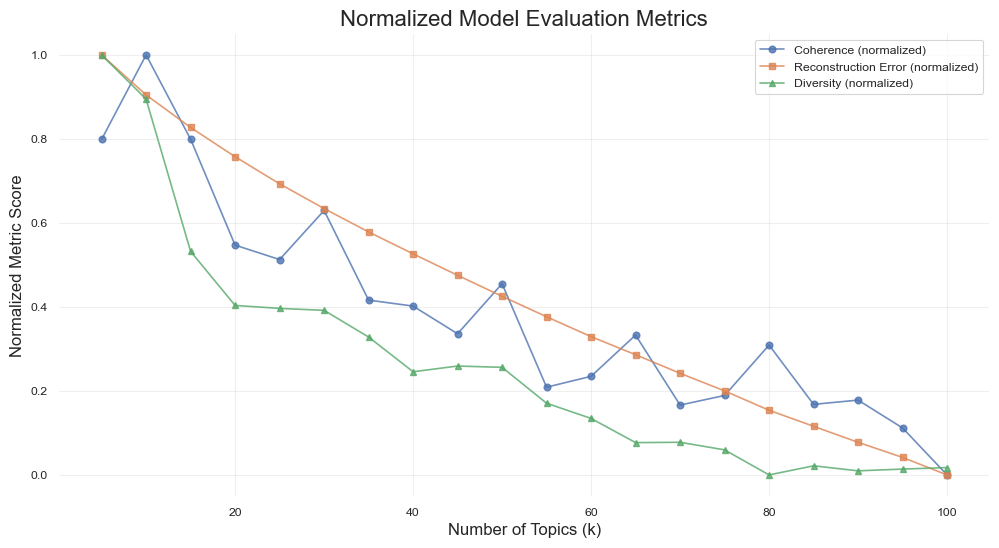

In [ ]:
# Plot model evaluation metrics
plt.figure(figsize=(12, 6))

plt.plot(summary['k'], summary['Coherence_norm'], marker='o', label='Coherence (normalized)', alpha=0.8)
plt.plot(summary['k'], summary['Error_norm'], marker='s', label='Reconstruction Error (normalized)', alpha=0.8)
plt.plot(summary['k'], summary['Diversity_norm'], marker='^', label='Diversity (normalized)', alpha=0.8)

plt.xlabel("Number of Topics (k)", fontsize=12)
plt.ylabel("Normalized Metric Score", fontsize=12)
plt.title("Normalized Model Evaluation Metrics", fontsize=16)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)

# Despine plot
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['left'].set_visible(False)

plt.legend()
plt.grid(visible=True)

plt.savefig('viz/NMF_evaluation_metrics_5-100-5.png', dpi=300)

plt.show()

### Narrow Range for k

In [ ]:
# Setup
topic_nums = range(2, 36, 1)
errors, coherences, diversities = [], [], []

tokenized_docs = df['post_tokens'].tolist()
dictionary = Dictionary(tokenized_docs)

In [ ]:
# Main loop for different values of k
for k in topic_nums:
    print(f"Running NMF for k={k}")

    # Fit NMF model
    nmf = NMF(n_components=k, random_state=42, init='nndsvda', max_iter=1000)
    W = nmf.fit_transform(X)
    H = nmf.components_
    errors.append(nmf.reconstruction_err_)

    # Get top words per topic
    topics = get_top_words(nmf, feature_names, n_top=15)

     # Topic labels for display
    topic_labels = {}
    for topic_idx, topic in enumerate(H):
        top_words = [feature_names[i] for i in topic.argsort()[:-4:-1]]
        topic_labels[topic_idx] = f"Topic {topic_idx}: {', '.join(top_words)}"

    # Compute metrics
    coherence_model = CoherenceModel(
        topics=topics,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='c_v'
    )

    coherences.append(coherence_model.get_coherence())
    
    diversities.append(topic_diversity(topics))


Running NMF for k=2
Running NMF for k=3
Running NMF for k=4
Running NMF for k=5
Running NMF for k=6
Running NMF for k=7
Running NMF for k=8
Running NMF for k=9
Running NMF for k=10
Running NMF for k=11
Running NMF for k=12
Running NMF for k=13
Running NMF for k=14
Running NMF for k=15
Running NMF for k=16
Running NMF for k=17
Running NMF for k=18
Running NMF for k=19
Running NMF for k=20
Running NMF for k=21
Running NMF for k=22
Running NMF for k=23
Running NMF for k=24
Running NMF for k=25
Running NMF for k=26
Running NMF for k=27
Running NMF for k=28
Running NMF for k=29
Running NMF for k=30
Running NMF for k=31
Running NMF for k=32
Running NMF for k=33
Running NMF for k=34
Running NMF for k=35


In [ ]:
# Build summary table
summary = pd.DataFrame({
    'k': topic_nums,
    'Coherence': coherences,
    'Diversity': diversities,
    'Reconstruction_Error': errors
})

# Normalize metrics (0–1 scale)
scaler = MinMaxScaler()
summary[['Coherence_norm', 'Diversity_norm', 'Error_norm']] = scaler.fit_transform(
    summary[['Coherence', 'Diversity', 'Reconstruction_Error']]
)

# Calculate weighted composite score
weights = {'Coherence': 0.6, 'Diversity': 0.3, 'Reconstruction_Error': 0.1}
summary['Composite_Score'] = (
    weights['Coherence'] * summary['Coherence_norm'] +
    weights['Diversity'] * summary['Diversity_norm'] +
    weights['Reconstruction_Error'] * summary['Error_norm']
)

# Print table with scores
summary[['k', 'Coherence', 'Diversity', 'Reconstruction_Error', 'Coherence_norm', 'Diversity_norm', 'Error_norm']]

,k,Coherence,Diversity,Reconstruction_Error,Coherence_norm,Diversity_norm,Error_norm
0,2,0.585609,1.000000,709.257158,0.351136,1.000000,1.000000
1,3,0.548816,0.933333,707.970007,0.000000,0.777778,0.953053
2,4,0.600948,0.875000,706.679551,0.497527,0.583333,0.905986
3,5,0.616234,0.900000,705.448546,0.643406,0.666667,0.861087
4,6,0.624229,0.900000,704.239675,0.719710,0.666667,0.816995
5,7,0.621742,0.900000,703.206698,0.695971,0.666667,0.779319
6,8,0.653599,0.900000,702.102422,1.000000,0.666667,0.739042
7,9,0.643475,0.877778,701.085024,0.903382,0.592593,0.701934
8,10,0.632794,0.870000,700.113358,0.801446,0.566667,0.666494
9,11,0.626896,0.845455,699.199158,0.745165,0.484848,0.633150


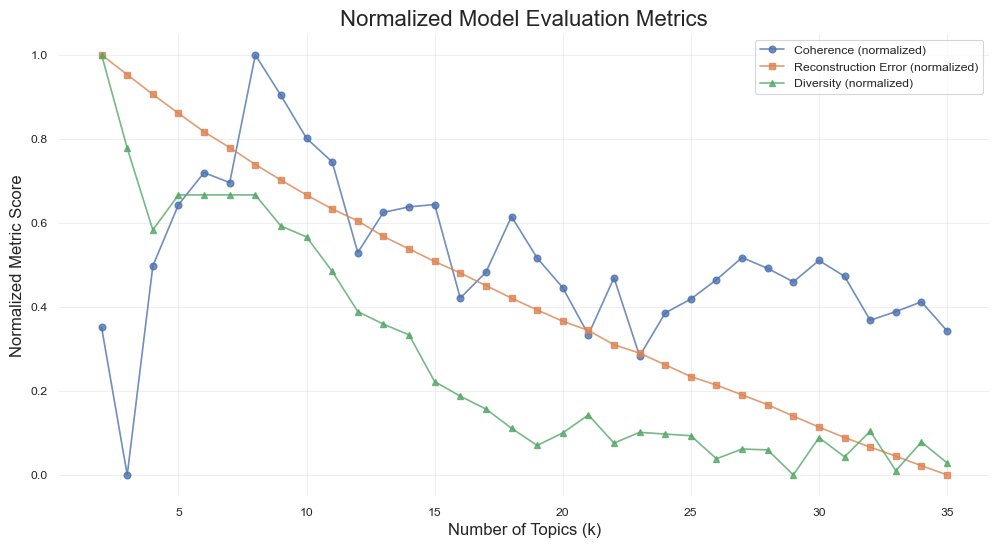

In [ ]:
# Plot model evaluation metrics
plt.figure(figsize=(12, 6))

plt.plot(summary['k'], summary['Coherence_norm'], marker='o', label='Coherence (normalized)', alpha=0.8)
plt.plot(summary['k'], summary['Error_norm'], marker='s', label='Reconstruction Error (normalized)', alpha=0.8)
plt.plot(summary['k'], summary['Diversity_norm'], marker='^', label='Diversity (normalized)', alpha=0.8)

# Highlight best k
plt.axvline(8, color='darkred', linestyle='--', label='Optimum k=8', alpha=0.8)

plt.xlabel("Number of Topics (k)", fontsize=12)
plt.ylabel("Normalized Metric Score", fontsize=12)
plt.title("Normalized Model Evaluation Metrics", fontsize=16)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)

# Despine plot
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['left'].set_visible(False)

plt.legend()
plt.grid(visible=True)

plt.savefig('viz/NMF_evaluation_metrics_2-35-1.png', dpi=300)

plt.show()

## NMF with Best Values for *k*

In [8]:
def get_topic_labels_nmf(model, vectorizer, n_words=5):

    words = vectorizer.get_feature_names_out()
    topic_labels = {}

    for i, topic in enumerate(model.components_):

        top_words = [
            words[j]
            for j in topic.argsort()[-n_words:][::-1]
        ]

        topic_labels[i] = " | ".join(top_words)

    return topic_labels

In [9]:
def show_topics(model, vectorizer, n_words=10):
    words = vectorizer.get_feature_names_out()

    for i, topic in enumerate(model.components_):
        top_words = [words[j] for j in topic.argsort()[-n_words:]]
        print(f"Topic {i}: {top_words}")

In [39]:
""" k = 8

nmf = NMF(n_components=k, random_state=42, init='nndsvda', max_iter=1000)
W = nmf.fit_transform(X)
H = nmf.components_

feature_names = vectorizer.get_feature_names_out()

num_top_words = 10

for topic_idx, topic in enumerate(H):
    top_indices = topic.argsort()[:-num_top_words - 1:-1]
    top_words = [feature_names[i] for i in top_indices]

topics = get_top_words(nmf, feature_names, n_top=10)

for topic in topics:
    print(topic) """

" k = 8\n\nnmf = NMF(n_components=k, random_state=42, init='nndsvda', max_iter=1000)\nW = nmf.fit_transform(X)\nH = nmf.components_\n\nfeature_names = vectorizer.get_feature_names_out()\n\nnum_top_words = 10\n\nfor topic_idx, topic in enumerate(H):\n    top_indices = topic.argsort()[:-num_top_words - 1:-1]\n    top_words = [feature_names[i] for i in top_indices]\n\ntopics = get_top_words(nmf, feature_names, n_top=10)\n\nfor topic in topics:\n    print(topic) "

In [ ]:
# df["dominant_topic"] = W.argmax(axis=1)
# df["topic_prob"] = W.max(axis=1)

# topic_labels = get_topic_labels_nmf(nmf, vectorizer)
# df["topic_label"] = df["dominant_topic"].map(topic_labels)

# df.head(5)

NameError: name 'W' is not defined

### Projection into 2-D Space

In [24]:
def plot_2D_projection_nmf(nmf, X, k, df, vectorizer):

    W = nmf.fit_transform(X)

    # --- assign topics ---
    df["topic"] = W.argmax(axis=1)
    df["topic_prob"] = W.max(axis=1)

    # --- labels ---
    topic_labels = get_topic_labels_nmf(nmf, vectorizer)
    df["topic_label"] = df["topic"].map(topic_labels)

    # --- colors ---
    topic_ids = sorted(df["topic"].unique())
    cmap = plt.colormaps.get_cmap("tab20")
    colors = [cmap(i) for i in range(len(topic_ids))]
    color_map = {t: colors[i % len(colors)] for i, t in enumerate(topic_ids)}
    topic_colors = df["topic"].map(color_map)

    sns.set_theme(style='whitegrid', context='paper')
    spine_color = '#cccccc'

    # --- PCA ---
    pca = PCA(n_components=2, random_state=42)
    W_pca = pca.fit_transform(W)

    # --- UMAP ---
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=15,
        min_dist=0.1,
        n_jobs=-1
    )
    W_umap = reducer.fit_transform(W)

    # --- plot ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    titles = ["PCA Projection", "UMAP Projection"]

    for ax, emb, title in zip(axes, [W_pca, W_umap], titles):
        ax.scatter(
            emb[:, 0],
            emb[:, 1],
            c=topic_colors,
            s=6,
            alpha=0.6
        )

        ax.set_title(f"{title} of NMF Topic Space (k={k})", fontsize=15)
        ax.set_xlabel("Component 1")
        ax.set_ylabel("Component 2")
        ax.grid(alpha=0.3)

        for spine in ax.spines.values():
            spine.set_color(spine_color)

    legend_elements = [
        Line2D(
            [0], [0],
            marker='o', color='w',
            markerfacecolor=cmap(t % 20),
            markersize=8,
            label=f"Topic {t}"
        )
        for t in topic_ids
    ]

    axes[1].legend(
        handles=legend_elements,
        title="Topics",
        bbox_to_anchor=(1.05, 1),
        loc='upper left',
        frameon=False
    )

    plt.tight_layout()

    plt.savefig(f"viz/NMF_pca_vs_umap_k{k}.png", dpi=300)
    
    plt.show()

Topic 0: ['eat', 'live', 'cell', 'long', 'brain', 'evolve', 'specie', 'animal', 'body', 'human']
Topic 1: ['away', 'slow', 'year', 'sound', 'move', 'object', 'fast', 'travel', 'speed', 'light']
Topic 2: ['system', 'gravity', 'solar', 'life', 'orbit', 'happen', 'sun', 'moon', 'planet', 'earth']
Topic 3: ['ocean', 'happen', 'ice', 'body', 'air', 'hot', 'temperature', 'cold', 'drink', 'water']
Topic 4: ['singularity', 'escape', 'star', 'matter', 'event', 'mass', 'horizon', 'happen', 'hole', 'black']
Topic 5: ['term', 'test', 'get', 'effect', 'long', 'people', 'virus', '19', 'vaccine', 'covid']
Topic 6: ['brain', 'don', 'eye', 'know', 'thing', 'different', 'feel', 'people', 'look', 'like']
Topic 7: ['travel', 'big', 'know', 'matter', 'create', 'energy', 'space', 'universe', 'possible', 'time']


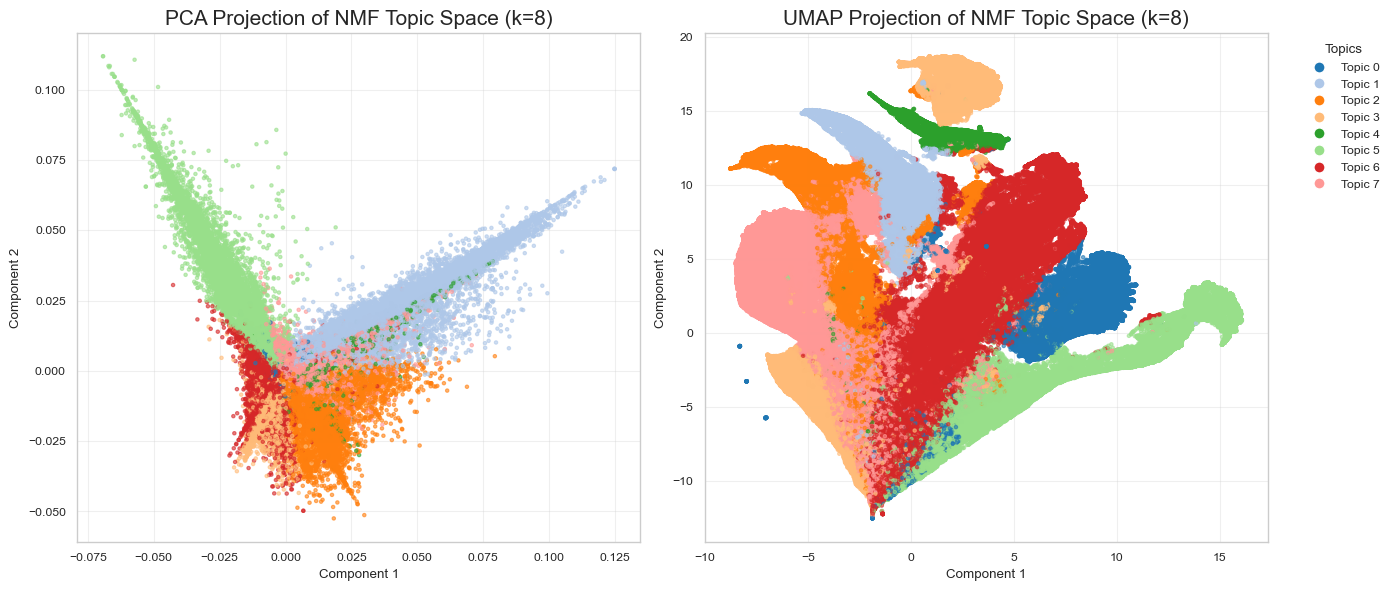

,id,author,question,link_flair_css_class,link_flair_text,description,created_utc,year,retrieved_on,org_post,...,clean_desc,question_tokens,desc_tokens,q_tuple,d_tuple,post_tokens,clean_text,topic,topic_prob,topic_label
1,4r857d,[deleted],UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,[removed],2016-07-04 17:05:51,2016,2016-09-03 18:04:14,UFO best scientific explanation. Atmospherical...,...,removed,"[ufo, good, scientific, explanation, atmospher...",[],"(ufo, good, scientific, explanation, atmospher...",(),"[ufo, good, scientific, explanation, atmospher...",ufo good scientific explanation atmospherical ...,6,0.005336,like | look | people | feel | different
2,4r0zwj,De_La_Soul_,It's a commonly known fact that metals oxidize...,chem,Chemistry,,2016-07-03 06:40:06,2016,2016-09-02 17:31:58,It's a commonly known fact that metals oxidize...,...,,"[commonly, know, fact, metal, oxidize, possibl...",[],"(commonly, know, fact, metal, oxidize, possibl...",(),"[commonly, know, fact, metal, oxidize, possibl...",commonly know fact metal oxidize possible dize...,7,0.019079,time | possible | universe | space | energy
3,540ohz,MacShakeIt,"China builds large telescope, but i have a que...",astro,Astronomy,[removed],2016-09-22 19:17:55,2016,2016-10-14 11:02:04,"China builds large telescope, but i have a que...",...,removed,"[china, build, large, telescope, question]",[],"(china, build, large, telescope, question)",(),"[china, build, large, telescope, question]",china build large telescope question,7,0.005613,time | possible | universe | space | energy
4,4r191k,[deleted],Geoscientists: Is there any current research i...,geo,Planetary Sci.,[removed],2016-07-03 08:26:38,2016,2016-09-02 17:34:09,Geoscientists: Is there any current research i...,...,removed,"[geoscientist, current, research, project, sho...",[],"(geoscientist, current, research, project, sho...",(),"[geoscientist, current, research, project, sho...",geoscientist current research project shortfal...,7,0.003387,time | possible | universe | space | energy
5,4r18ga,Mitzuiro,"Why are there so many ""accident"" babies yet so...",bio,Biology,[removed],2016-07-03 08:19:16,2016,2016-09-02 17:33:59,"Why are there so many ""accident"" babies yet so...",...,removed,"[accident, baby, people, struggle, conceive]",[],"(accident, baby, people, struggle, conceive)",(),"[accident, baby, people, struggle, conceive]",accident baby people struggle conceive,6,0.013632,like | look | people | feel | different


In [25]:
k = 8

nmf = NMF(n_components=k, random_state=42, init='nndsvda', max_iter=1000)

W = nmf.fit_transform(X)

df["topic"] = W.argmax(axis=1)
df["topic_prob"] = W.max(axis=1)

topic_labels = get_topic_labels_nmf(nmf, vectorizer)
df["topic_label"] = df["topic"].map(topic_labels)

show_topics(nmf, vectorizer)

plot_2D_projection_nmf(nmf, X, k, df, vectorizer)

df.head(5)

### Löschen

In [12]:
topic_ids = sorted(df['dominant_topic'].unique())

cmap = plt.colormaps.get_cmap('tab20')
colors = [cmap(i) for i in range(len(topic_ids))]

color_map = {t: colors[i % len(colors)] for i, t in enumerate(topic_ids)}

topic_colors = df['dominant_topic'].map(color_map)

In [ ]:
pca = PCA(n_components=2, random_state=42)
W_pca = pca.fit_transform(W)

reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, n_jobs=-1)
W_umap = reducer.fit_transform(W)

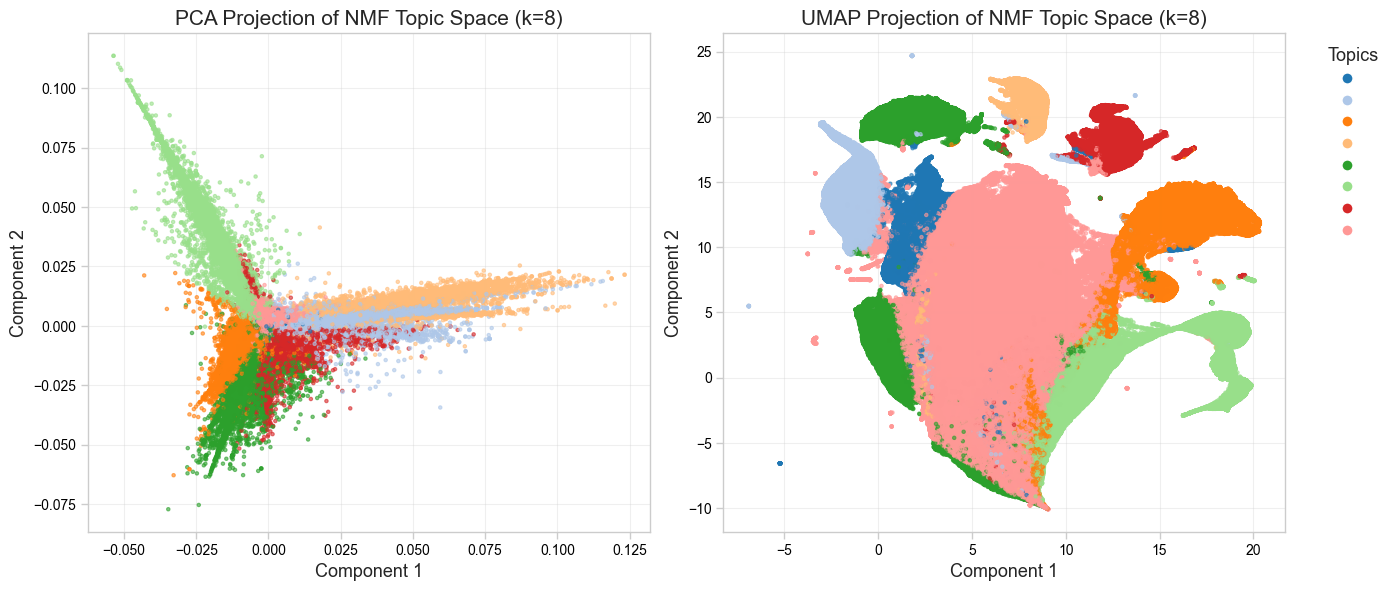

In [24]:
sns.set_theme(style='whitegrid', context='paper')
spine_color = '#cccccc'

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
titles = ["PCA Projection", "UMAP Projection"]

for ax, emb, title in zip(axes, [W_pca, W_umap], titles):
    ax.scatter(
        emb[:, 0], emb[:, 1],
        c=topic_colors,
        s=6,
        alpha=0.6
    )

    ax.set_title(f"{title} of NMF Topic Space (k={k})", fontsize=15)
    ax.set_xlabel("Component 1", fontsize=13)
    ax.set_ylabel("Component 2", fontsize=13)

    ax.grid(alpha=0.3)

    for spine in ax.spines.values():
        spine.set_color("#cccccc")

    ax.tick_params(axis='both', which='both', labelsize=10)

legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=color_map[t],
        markersize=8
    )
    for t in topic_ids
]

axes[1].legend(
    handles=legend_elements,
    title="Topics",
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=11,
    title_fontsize=13,
    frameon=False
)

for ax in axes:
    ax.tick_params(
        axis='both',
        which='both',
        bottom=True,
        left=True,
        color=spine_color,
        labelcolor='black'
    )

plt.tight_layout()
plt.savefig(f'viz/NMF_pca_vs_umap_k{k}.png', dpi=300)
plt.show()

## Plot Topics

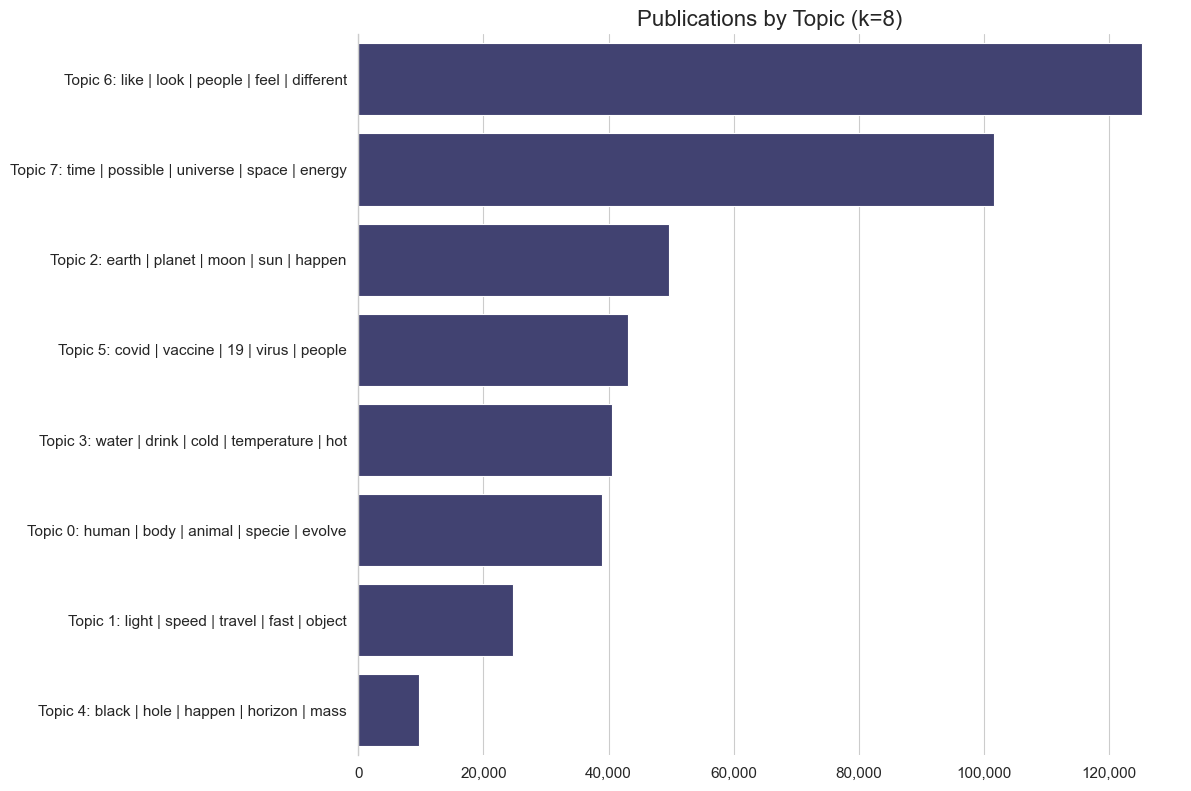

In [26]:
words = vectorizer.get_feature_names_out()

topic_labels = {}

for i, topic in enumerate(nmf.components_):
    top_words = [words[j] for j in topic.argsort()[-5:][::-1]]
    topic_labels[i] = f"Topic {i}: " + " | ".join(top_words)


# Create a temporary mapping JUST for plotting
plot_labels = df["topic"].map(topic_labels)

color = plt.colormaps["tab20b"](0)

fig, ax = plt.subplots(figsize=(12, 8))

sns.countplot(
    y=plot_labels,
    order=plot_labels.value_counts().index,
    ax=ax,
    color=color
)

ax.set_title(f"Publications by Topic (k={k})", fontsize=16)
ax.set_xlabel("")
ax.set_ylabel("")

ax.tick_params(axis='y', labelsize=11)
ax.tick_params(axis='x', labelsize=11)

ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.savefig(f"viz/NMF_posts_per_topic_k{k}.png", dpi=300)
plt.show()

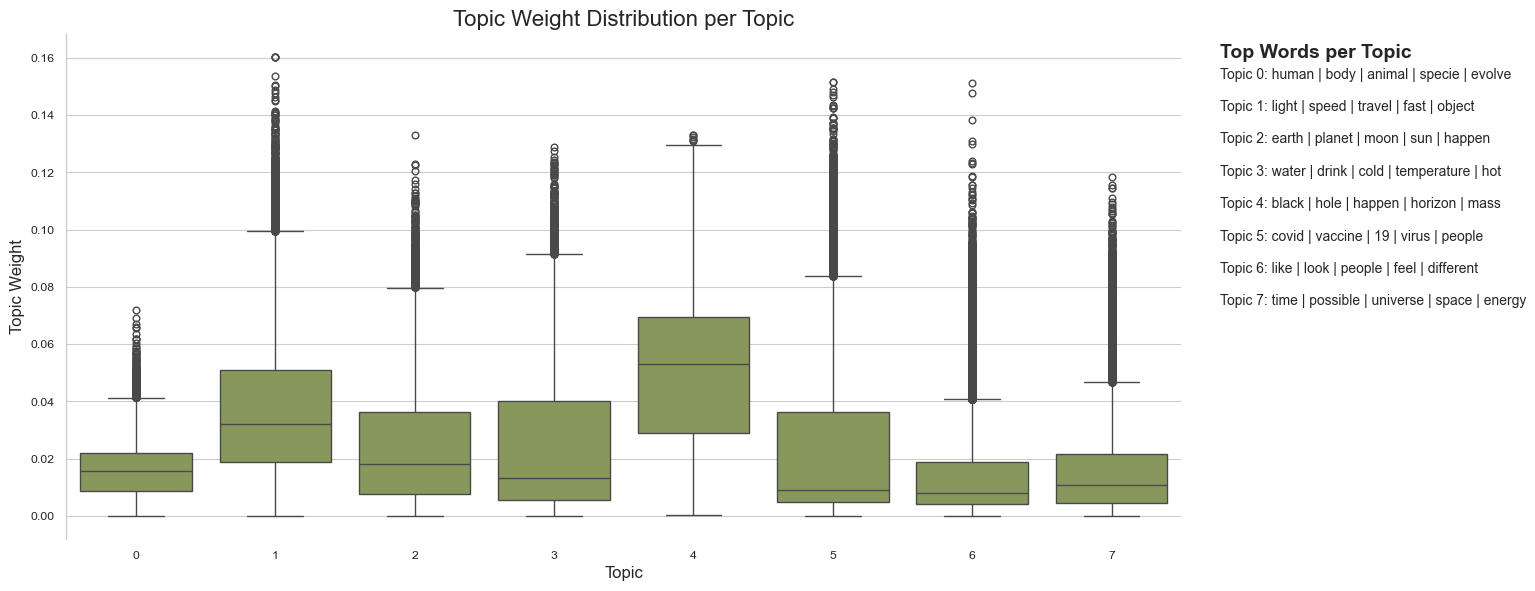

In [28]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="topic",
    y="topic_prob",
    color=plt.colormaps["tab20b"](5),
    ax=ax
)

ax.set_title("Topic Weight Distribution per Topic", fontsize=16)
ax.set_xlabel("Topic", fontsize=12)
ax.set_ylabel("Topic Weight", fontsize=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

topic_labels = get_topic_labels_nmf(nmf, vectorizer)

fig.text(
    1.02, 0.92,
    "Top Words per Topic",
    fontsize=14,
    fontweight="bold",
    va="top",
    ha="left"
)

legend_text = "\n\n".join(
    [f"Topic {i}: {topic_labels[i]}" for i in sorted(topic_labels)]
)

fig.text(
    1.02, 0.88,
    legend_text,
    fontsize=10,
    va="top",
    ha="left"
)

fig.subplots_adjust(right=0.7)

plt.tight_layout()
plt.savefig("viz/NMF_topic_weight.png", dpi=300)
plt.show()